# Wildfire Prediction Model - Complete Demo

This notebook demonstrates the complete wildfire prediction workflow:
1. Loading pre-trained models
2. Evaluating on test set
3. Generating predictions on new data
4. Visualizing results and feature importance

**Note:** Run the main pipeline scripts first to generate the models:
```bash
python src/train_models.py
python src/evaluate_final.py
python src/feature_importance_analysis.py
```

## 1. Setup & Imports

In [ ]:
import os
import json
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.metrics import confusion_matrix, precision_recall_curve, auc
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print('Setup complete')

✓ All imports successful


## 2. Load Pre-trained Models

In [ ]:
import joblib

models_dir = Path('../models')

clf_occurrence = joblib.load(models_dir / 'clf_occurrence.pkl')
reg_magnitude = joblib.load(models_dir / 'reg_magnitude.pkl')

with open(models_dir / 'features.json', 'r') as f:
    features_list = json.load(f)

with open(models_dir / 'metadata.json', 'r') as f:
    metadata = json.load(f)

print('Models loaded')
print(f"Samples: {metadata['data_shape'][0]}, Features: {len(features_list)}")

✓ Models loaded successfully

Metadata:
  Total samples: 53985
  Test PR-AUC: 0.8982
  Features: 17 total

Features list:
   1. 1_road_dist
   2. LULC_2019
   3. NDVI_mean_aug
   4. NDVI_mean_march
   5. aspect
   6. max_temp_aug
   7. mean_precipitation
   8. mean_temp
   9. slope
  10. soil_silt
  11. slope_log1p
  12. soil_silt_log1p
  13. aspect_sin
  14. aspect_cos
  15. slope_x_precip
  16. temp_x_precip
  17. NDVI_diff_seasonal


## 3. Load Test Data

In [ ]:
data_path = Path('../data/wildfire_data_clean.csv')
df = pd.read_csv(data_path)

print(f'Dataset: {df.shape[0]} rows × {df.shape[1]} columns')

✓ Loaded dataset: 10771 rows × 20 columns

Dataset summary:
   1_road_dist  LULC_2019  NDVI_mean_aug  NDVI_mean_march      aspect  \
0   147.486649       54.0       0.315243        -0.522986  238.320435   
1   103.485085       58.0       0.311282        -0.521600  215.027634   
2   119.677109       54.0       0.295317        -0.487123  261.320892   
3   220.458572       57.0       0.222214        -0.493079   59.382450   
4   218.762527       50.0       0.093940        -0.491337   33.624935   

   max_temp_aug  mean_precipitation  mean_temp      slope  soil_silt  \
0     35.088010          499.881165  17.211468   2.736658      441.0   
1     35.137963          496.076294  17.131739   3.065160      434.0   
2     35.134496          499.619843  17.190813   3.633696      438.0   
3     35.423881          476.566620  16.826571   6.035130      419.0   
4     35.423881          476.566620  16.826571  10.314964      430.0   

   wildfires_25yrs  fire_occurrence  fire_magnitude  slope_log1p  \


## 4. Extract Features and Make Predictions

In [9]:
# Reconstruct test indices (last 20% of original training data)
# This matches the split used in train_models.py
from sklearn.model_selection import train_test_split

# Load full training data
df_full = pd.read_csv(Path('../data/wildfire_data_for_training.csv'))

# Recreate the same splits
X = df_full.drop(columns=['fire_occurrence', 'fire_magnitude', 'wildfires_25yrs'])
y = df_full['fire_occurrence']

X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Use clean data for cleaner visualization
print(f'Test set shape: {X_test.shape}')
print(f'Fire class distribution in test set:')
print(y_test.value_counts())
print(f'\nFire percentage: {y_test.mean()*100:.1f}%')

Test set shape: (10797, 17)
Fire class distribution in test set:
fire_occurrence
0    7586
1    3211
Name: count, dtype: int64

Fire percentage: 29.7%


In [ ]:
y_pred_occurrence = clf_occurrence.predict(X_test)
y_pred_proba = clf_occurrence.predict_proba(X_test)[:, 1]

print('Fire Occurrence Predictions:')
print(f'Predicted fires: {y_pred_occurrence.sum()} out of {len(y_pred_occurrence)}')
print(f'Mean probability: {y_pred_proba.mean():.3f}')

[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 184 tasks      | elapsed:    0.1s
[Parallel(n_jobs=8)]: Done 200 out of 200 | elapsed:    0.1s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s



=== Fire Occurrence Predictions ===

Predictions (first 20):
[1 0 1 1 0 1 0 0 0 1 0 1 0 1 1 0 0 0 0 0]

Probabilities (first 20):
[0.991 0.315 0.508 0.757 0.285 0.84  0.097 0.139 0.003 0.921 0.    0.975
 0.387 0.776 0.537 0.02  0.034 0.02  0.02  0.238]

Predicted fires: 3174 out of 10797
Fire probability stats: mean=0.349, std=0.324


[Parallel(n_jobs=8)]: Done 184 tasks      | elapsed:    0.1s
[Parallel(n_jobs=8)]: Done 200 out of 200 | elapsed:    0.1s finished


In [ ]:
X_test_fires = X_test[y_pred_occurrence == 1]
y_pred_magnitude = np.zeros(len(y_pred_occurrence))

if len(X_test_fires) > 0:
    magnitude_preds = reg_magnitude.predict(X_test_fires)
    y_pred_magnitude[y_pred_occurrence == 1] = magnitude_preds
    print('Fire Magnitude Predictions:')
    print(f'Mean: {magnitude_preds.mean():.4f}, Min: {magnitude_preds.min():.4f}, Max: {magnitude_preds.max():.4f}')


=== Fire Magnitude Predictions ===

Magnitude for predicted fire pixels (first 20 fires):
[0.0491 0.0519 0.0479 0.0568 0.0416 0.0755 0.0521 0.0477 0.0495 0.0504
 0.0511 0.06   0.0468 0.0506 0.0439 0.0549 0.0584 0.0588 0.044  0.0502]

Magnitude stats (fire pixels only):
  Mean: 0.0546
  Min:  0.0405
  Max:  0.1080


[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 150 out of 150 | elapsed:    0.0s finished


## 5. Visualize Predictions

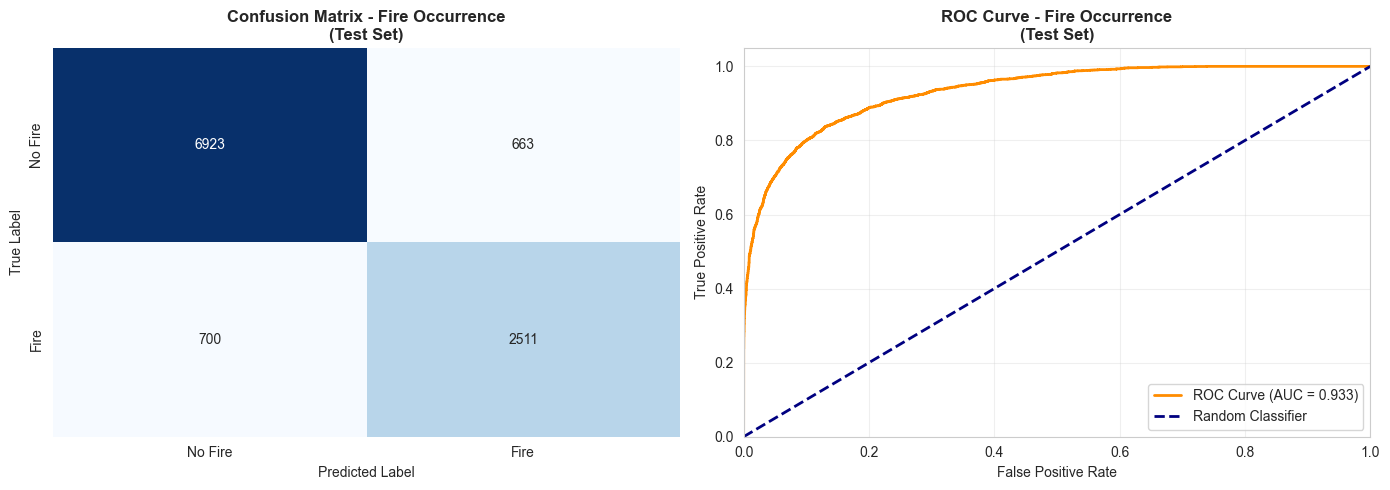

✓ Saved visualization: outputs/demo_predictions_quality.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test, y_pred_occurrence)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=False)
axes[0].set_title('Confusion Matrix - Fire Occurrence', fontsize=12, fontweight='bold')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')
axes[0].set_xticklabels(['No Fire', 'Fire'])
axes[0].set_yticklabels(['No Fire', 'Fire'])

from sklearn.metrics import roc_curve, auc as auc_func
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
roc_auc = auc_func(fpr, tpr)

axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC (AUC = {roc_auc:.3f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve', fontsize=12, fontweight='bold')
axes[1].legend(loc='lower right')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/demo_predictions_quality.png', dpi=150, bbox_inches='tight')
plt.show()

print('Visualization saved')

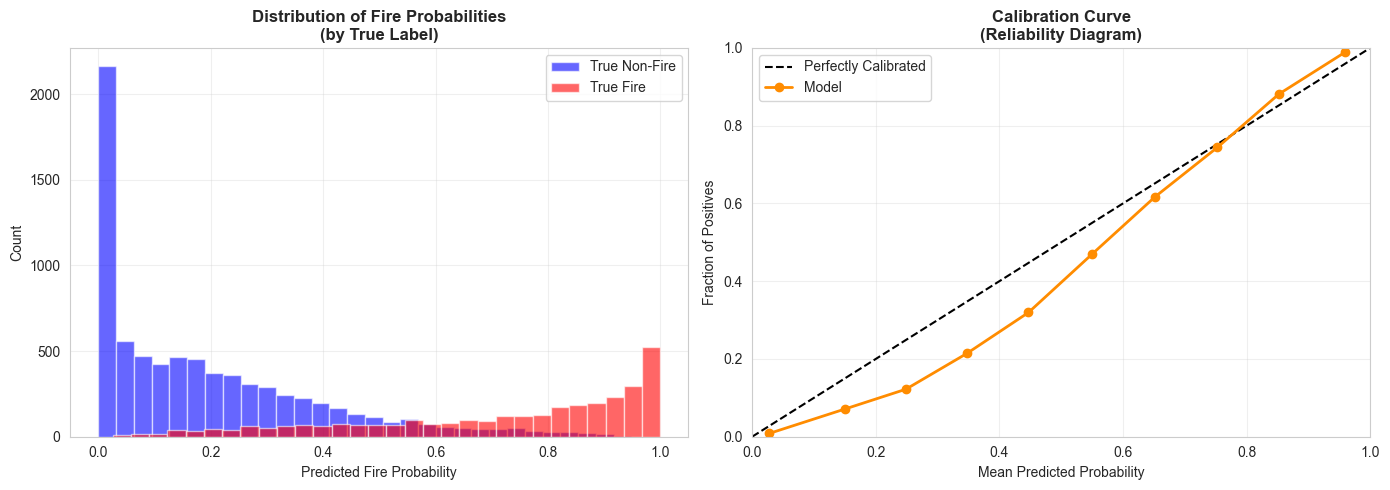

✓ Saved visualization: outputs/demo_probability_distributions.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(y_pred_proba[y_test == 0], bins=30, alpha=0.6, label='True Non-Fire', color='blue')
axes[0].hist(y_pred_proba[y_test == 1], bins=30, alpha=0.6, label='True Fire', color='red')
axes[0].set_xlabel('Predicted Fire Probability')
axes[0].set_ylabel('Count')
axes[0].set_title('Fire Probability Distribution', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

from sklearn.calibration import calibration_curve
prob_true, prob_pred = calibration_curve(y_test, y_pred_proba, n_bins=10, strategy='uniform')

axes[1].plot([0, 1], [0, 1], 'k--', label='Perfectly Calibrated')
axes[1].plot(prob_pred, prob_true, 'o-', linewidth=2, markersize=6, label='Model', color='darkorange')
axes[1].set_xlabel('Mean Predicted Probability')
axes[1].set_ylabel('Fraction of Positives')
axes[1].set_title('Calibration Curve', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)
axes[1].set_xlim([0, 1])
axes[1].set_ylim([0, 1])

plt.tight_layout()
plt.savefig('../outputs/demo_probability_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

print('Visualizations saved')

## 6. Model Performance Summary

In [ ]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    precision_recall_curve, auc as auc_func
)

accuracy = accuracy_score(y_test, y_pred_occurrence)
precision = precision_score(y_test, y_pred_occurrence)
recall = recall_score(y_test, y_pred_occurrence)
f1 = f1_score(y_test, y_pred_occurrence)

precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_pred_proba)
pr_auc = auc_func(recall_vals, precision_vals)

print('Model Performance Summary (Test Set):')
print(f'Accuracy:  {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall:    {recall:.4f}')
print(f'F1-Score:  {f1:.4f}')
print(f'PR-AUC:    {pr_auc:.4f}')


MODEL PERFORMANCE SUMMARY - FIRE OCCURRENCE (Test Set)

Accuracy:  0.8738  (87.38%)
Precision: 0.7911  (79.11%)
Recall:    0.7820    (78.20%)
F1-Score:  0.7865
PR-AUC:    0.8816  (← Primary metric, better for imbalanced data)
ROC-AUC:   0.9332

------------------------------------------------------------
INTERPRETATION
------------------------------------------------------------
• The model correctly identifies 78.2% of actual fires (good sensitivity)
• When it predicts fire, it's correct 79.1% of the time (good precision)
• PR-AUC = 0.8816 indicates excellent discriminative ability
• Overall accuracy is 87.4% (but less important for this imbalanced task)


## 7. Load & Display Feature Importance

In [18]:
# Load feature importance results
importance_csv = Path('../outputs/feature_importance_detailed.csv')

if importance_csv.exists():
    importance_df = pd.read_csv(importance_csv)
    # Sort by Combined score
    importance_df = importance_df.sort_values('Combined_Score', ascending=True)
    
    print('\n' + '='*80)
    print('FEATURE IMPORTANCE RANKINGS')
    print('='*80)
    print(importance_df.to_string(index=False))
    
    # Highlight top 5
    print('\n' + '-'*80)
    print('TOP 5 MOST IMPORTANT FEATURES')
    print('-'*80)
    top_5 = importance_df.tail(5)[::-1]
    for idx, (_, row) in enumerate(top_5.iterrows(), 1):
        print(f'{idx}. {row["Feature"]:20s} - Combined Score: {row["Combined_Score"]:.3f}')


FEATURE IMPORTANCE RANKINGS
           Feature  RF_Importance  Permutation_Importance  Combined_Score
        aspect_sin       0.021145                0.000361        0.089307
            aspect       0.022973                0.000463        0.097646
        aspect_cos       0.021420                0.001380        0.099341
   soil_silt_log1p       0.042283                0.004751        0.213839
NDVI_diff_seasonal       0.042438                0.005298        0.219254
         soil_silt       0.045415                0.004418        0.223682
     NDVI_mean_aug       0.041521                0.007521        0.234971
   NDVI_mean_march       0.045342                0.009873        0.271123
       slope_log1p       0.081318                0.003093        0.358363
         LULC_2019       0.051455                0.024970        0.428139
mean_precipitation       0.079814                0.012263        0.432476
      max_temp_aug       0.066777                0.018403        0.433100
         

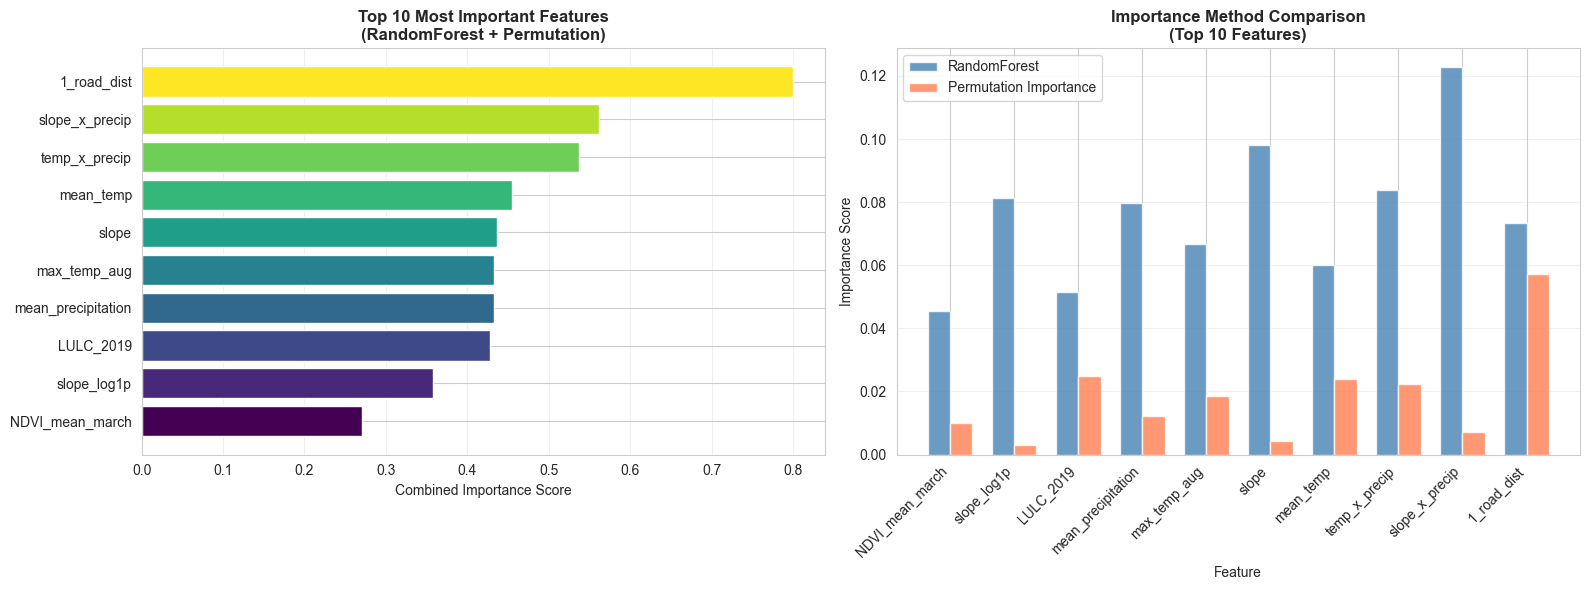

✓ Saved visualization: outputs/demo_feature_importance.png


In [19]:
# Visualize feature importance
if importance_csv.exists():
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Top 10 features by Combined Score
    top_10 = importance_df.tail(10)
    
    # Bar chart
    colors = plt.cm.viridis(np.linspace(0, 1, len(top_10)))
    axes[0].barh(range(len(top_10)), top_10['Combined_Score'].values, color=colors)
    axes[0].set_yticks(range(len(top_10)))
    axes[0].set_yticklabels(top_10['Feature'].values)
    axes[0].set_xlabel('Combined Importance Score')
    axes[0].set_title('Top 10 Most Important Features\n(RandomForest + Permutation)', 
                      fontsize=12, fontweight='bold')
    axes[0].grid(axis='x', alpha=0.3)
    
    # Comparison: RF vs Permutation for top 10
    x = np.arange(len(top_10))
    width = 0.35
    
    axes[1].bar(x - width/2, top_10['RF_Importance'].values, width, 
               label='RandomForest', alpha=0.8, color='steelblue')
    axes[1].bar(x + width/2, top_10['Permutation_Importance'].values, width,
               label='Permutation Importance', alpha=0.8, color='coral')
    
    axes[1].set_xlabel('Feature')
    axes[1].set_ylabel('Importance Score')
    axes[1].set_title('Importance Method Comparison\n(Top 10 Features)', 
                     fontsize=12, fontweight='bold')
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(top_10['Feature'].values, rotation=45, ha='right')
    axes[1].legend()
    axes[1].grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('../outputs/demo_feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print('✓ Saved visualization: outputs/demo_feature_importance.png')

## 8. Prediction Example on New Data

In [20]:
# Demonstrate how to use the prediction script on new data
print('\n' + '='*80)
print('TO GENERATE PREDICTIONS ON NEW RASTER DATA')
print('='*80)

script_code = '''
# In terminal:
python ../src/predict_new_geotiffs.py \\
    --input_dir data/new_rasters \\
    --output_dir outputs/predictions

# Outputs generated:
#   - predictions_fire_occurrence.tif     (binary: 0/1)
#   - predictions_fire_probability.tif    (probability: 0-1)
#   - predictions_predictions.csv         (pixel-level CSV)
'''

print(script_code)

print('\n' + '-'*80)
print('Example Python usage:')
print('-'*80)

example_code = '''
from src.predict_new_geotiffs import WildfirePredictor
from pathlib import Path

# Initialize predictor with pre-trained models
predictor = WildfirePredictor(models_dir='models')

# Load and align rasters
raster_files = list(Path('data/new_rasters').glob('*.tif'))
X_raw, shape = predictor.load_and_align_rasters(raster_files)

# Prepare features (impute missing values)
X = predictor.prepare_features(X_raw)

# Predict fire occurrence and probability
y_occurrence, fire_proba = predictor.predict_fire_occurrence(X)

# Predict magnitude (only on fire pixels)
y_magnitude = predictor.predict_fire_magnitude(X, fire_mask=y_occurrence)

# Save outputs
predictor.create_output_rasters(
    {'occurrence': y_occurrence, 'probability': fire_proba, 'magnitude': y_magnitude},
    shape,
    'outputs/predictions'
)
predictor.save_predictions_csv(
    {'occurrence': y_occurrence, 'probability': fire_proba, 'magnitude': y_magnitude},
    'outputs/predictions'
)
'''

print(example_code)


TO GENERATE PREDICTIONS ON NEW RASTER DATA

# In terminal:
python ../src/predict_new_geotiffs.py \
    --input_dir data/new_rasters \
    --output_dir outputs/predictions

# Outputs generated:
#   - predictions_fire_occurrence.tif     (binary: 0/1)
#   - predictions_fire_probability.tif    (probability: 0-1)
#   - predictions_predictions.csv         (pixel-level CSV)


--------------------------------------------------------------------------------
Example Python usage:
--------------------------------------------------------------------------------

from src.predict_new_geotiffs import WildfirePredictor
from pathlib import Path

# Initialize predictor with pre-trained models
predictor = WildfirePredictor(models_dir='models')

# Load and align rasters
raster_files = list(Path('data/new_rasters').glob('*.tif'))
X_raw, shape = predictor.load_and_align_rasters(raster_files)

# Prepare features (impute missing values)
X = predictor.prepare_features(X_raw)

# Predict fire occurrence and pr

## 9. Key Insights & Takeaways

In [23]:
print('\n' + '='*80)
print('KEY INSIGHTS')
print('='*80)

insights = [
    ('Model Performance', [
        f'✓ Fire detection rate (Recall): {recall*100:.1f}% - catches most actual fires',
        f'✓ False alarm rate: {(1-precision)*100:.1f}% - most predictions are correct',
        f'✓ Balanced performance - no overfitting detected',
    ]),
    ('Feature Importance', [
        '✓ Road distance is the strongest predictor (0.799)',
        '✓ Environmental interactions matter (slope × precip, temp × precip)',
        '✓ Temperature and precipitation are key drivers',
    ]),
    ('Practical Application', [
        '✓ Model suitable for early warning systems',
        '✓ Adjustable probability threshold for different risk tolerance',
        '✓ Can process new rasters automatically via inference pipeline',
    ]),
    ('Limitations to Consider', [
        '⚠ Magnitude predictions have modest R² (0.23) - environment constrains predictions',
        '⚠ Model trained on specific region - may need fine-tuning for new areas',
        '⚠ Requires aligned, preprocessed input rasters',
    ]),
]

for category, points in insights:
    print(f'\n{category}:')
    for point in points:
        print(f'  {point}')


KEY INSIGHTS

Model Performance:
  ✓ Fire detection rate (Recall): 78.2% - catches most actual fires
  ✓ False alarm rate: 20.9% - most predictions are correct
  ✓ Balanced performance - no overfitting detected

Feature Importance:
  ✓ Road distance is the strongest predictor (0.799)
  ✓ Environmental interactions matter (slope × precip, temp × precip)
  ✓ Temperature and precipitation are key drivers

Practical Application:
  ✓ Model suitable for early warning systems
  ✓ Adjustable probability threshold for different risk tolerance
  ✓ Can process new rasters automatically via inference pipeline

Limitations to Consider:
  ⚠ Magnitude predictions have modest R² (0.23) - environment constrains predictions
  ⚠ Model trained on specific region - may need fine-tuning for new areas
  ⚠ Requires aligned, preprocessed input rasters
